#### Task: Implement a convolutional neural network to train a predictor for the CIFAR 10 dataset.

The CNN includes 3 convolutional layers (each followed by a pooling layer):

Conv1: Input channel: 3; Output Chnnel 16; Kernel size 4; Padding: 1; Stride: 2; ReLU activation

Pool1: MaxPool, Kernel size: (2,2); Padding: 0; Stride: 2

Conv2: Input channel: 16; Output Chnnel 32; Kernel size 4; Padding: 0; Stride: 1; ReLU activation

Pool2: MaxPool, Kernel size: (2,2); Padding: 0; Stride: 1

Conv2: Input channel: 32; Output Chnnel 32; Kernel size 2; Padding: 0; Stride: 1; ReLU activation

Pool3: MaxPool, Kernel size: (2,2); Padding: 0; Stride: 1

The CNN has two fully connected layers. The width of the hidden layer is 128, followed by ReLU activation

Calculate the dimension after flattening and implement the CNN

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

In [4]:
# -----------------------------
# Download the CIFAR10 dataset
# -----------------------------

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [5]:
# -----------------------------
# Print the size of one sample
# -----------------------------

images, labels = next(iter(trainloader))
# Your reported result--------------------------------------------------
# Report the printed image size
print('Image size is '+str(images[0].shape))

Image size is torch.Size([3, 32, 32])


In [9]:
# -----------------------------
# Build the CNN
# -----------------------------

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Your codes start here----------------------------------------------
        # Define the layers in the 
        # Convolution layers
        self.conv1 = nn.Conv2d(3, 16, kernel_size=4, padding=1, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, padding=0, stride=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=2, padding=0, stride=1)

        # Pooling
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.MaxPool2d(2, 1)
        self.pool3 = nn.MaxPool2d(2, 1)

        # Fully connected layers
        self.fc1 = nn.Linear(32 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Conv Block 1
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)     

        # Conv Block 2
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)     

        # Conv Block 3
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.pool3(x)     

        # Flatten
        x = torch.flatten(x, 1)

        # Fully connected
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)

        return x

In [10]:
# -----------------------------
# Initialize the CNN model
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

In [12]:
# -----------------------------
# Train the CNN
# -----------------------------

# Define CrossEntropy Loss.
criterion = nn.CrossEntropyLoss()
# Your codes start here---------------------------------------
# Define Adam optimizer with your selected learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Your codes start here---------------------------------------
# Choose your number of epochs
Epoch = 10


# Training Loop
train_losses = []
test_accs = []
for epoch in range(Epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()

    epoch_test_acc = 100. * test_correct / test_total
    test_accs.append(epoch_test_acc)

    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Train Acc: {100.*correct/total:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

Epoch 1 | Loss: 1.6699 | Train Acc: 37.72% | Test Acc: 47.64%
Epoch 2 | Loss: 1.3687 | Train Acc: 49.91% | Test Acc: 52.94%
Epoch 3 | Loss: 1.2633 | Train Acc: 54.28% | Test Acc: 53.70%
Epoch 4 | Loss: 1.1702 | Train Acc: 58.23% | Test Acc: 58.82%
Epoch 5 | Loss: 1.1104 | Train Acc: 60.59% | Test Acc: 58.96%
Epoch 6 | Loss: 1.0636 | Train Acc: 62.21% | Test Acc: 61.46%
Epoch 7 | Loss: 1.0237 | Train Acc: 63.67% | Test Acc: 61.37%
Epoch 8 | Loss: 0.9913 | Train Acc: 64.94% | Test Acc: 62.88%
Epoch 9 | Loss: 0.9611 | Train Acc: 65.93% | Test Acc: 62.64%
Epoch 10 | Loss: 0.9389 | Train Acc: 66.75% | Test Acc: 64.62%


In [13]:
# -----------------------------
# Test the CNN
# -----------------------------

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, targets in testloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

# Your reported result--------------------------------------------------
# Report the printed test accuracy
print(f"Test Accuracy: {100.*correct/total:.2f}%")

Test Accuracy: 64.62%


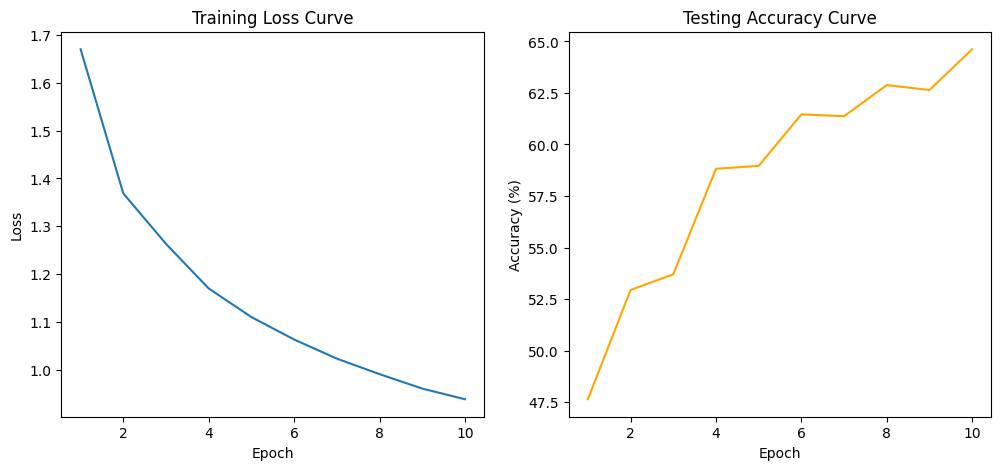

In [14]:
# -----------------------------
# Plot loss and accuracy curves
# -----------------------------

epochs_range = range(1, Epoch + 1)

plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

# Plot 2: Testing Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, test_accs, label='Test Accuracy', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Testing Accuracy Curve")

#Your reported result----------------------------------------
#Copy the trianing loss curve and testing accuracy curve to your report.
plt.show()